<a href="https://colab.research.google.com/github/cpython-projects/python_da_17_03_26/blob/main/lesson_17_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Легенда

**[Students Performance in Exams](https://github.com/cpython-projects/python_da_06_11_25/blob/main/StudentsPerformance.csv)**

Датасет містить інформацію про результати учнів та деякі соціальні характеристики, які можуть впливати на успішність.

## Опис змінних

* **gender** — стать учня
* **race/ethnicity** — етнічна група учня
* **parental level of education** — рівень освіти батьків
* **lunch** — тип харчування в школі
* **test preparation course** — чи проходив учень підготовчий курс перед іспитом
* **math score** — бал за іспит з математики
* **reading score** — бал за іспит з читання
* **writing score** — бал за іспит з письма

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/cpython-projects/python_da_06_11_25/refs/heads/main/StudentsPerformance.csv")

In [3]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.gender.unique()

array(['female', 'male'], dtype=object)

In [6]:
df['gender'] = df.gender.astype('category')

In [8]:
df['race/ethnicity']= df['race/ethnicity'].astype('category')

In [10]:
df['parental level of education'] = df['parental level of education'].astype('category')

# Task 1  

**Адміністрація школи хоче зрозуміти:**
> якщо учень добре справляється з читанням, чи можна очікувати, що він так само добре напише письмову частину іспиту?

In [11]:
df.columns.to_list()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [12]:
import plotly.express as px

In [13]:
fig = px.scatter(df, x='reading score', y='writing score')
fig.show()

<Axes: >

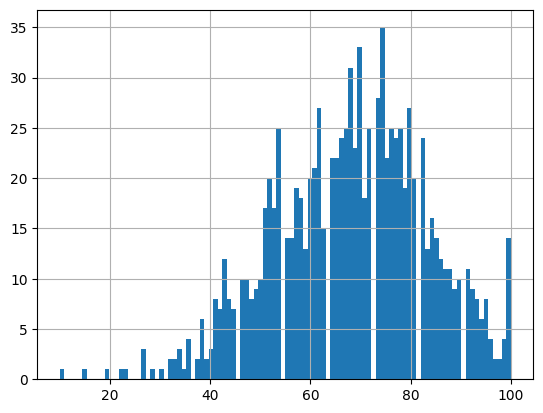

In [15]:
df['writing score'].hist(bins=100)

<Axes: >

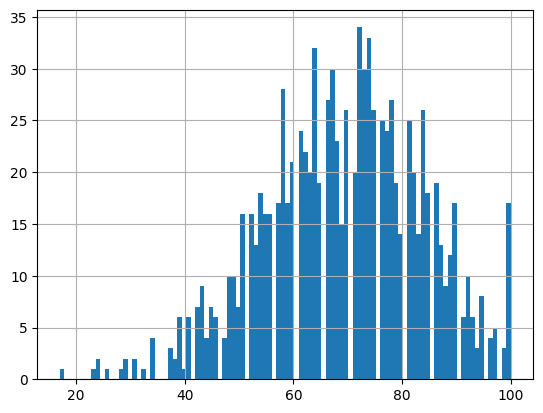

In [16]:
df['reading score'].hist(bins=100)

In [17]:
df[['writing score', 'reading score']].corr()

,writing score,reading score
writing score,1.000000,0.954598
reading score,0.954598,1.000000


# Task 2  

**Методичний відділ школи обговорює:**
> чи мають учні з високими результатами з письма стабільно кращі результати з математики, чи ці навички розвиваються незалежно?

In [18]:
fig = px.scatter(df, x='math score', y='writing score')
fig.show()

<Axes: >

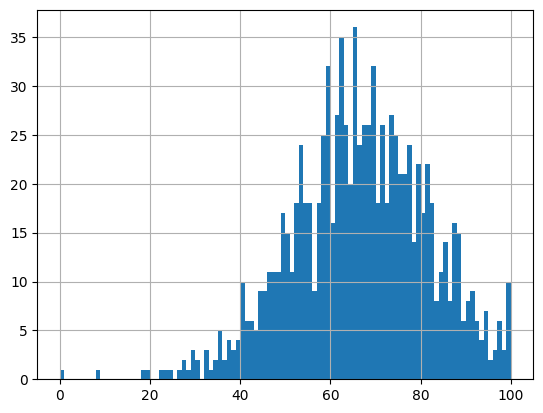

In [19]:
df['math score'].hist(bins=100)

In [20]:
df[['writing score', 'math score']].corr()

,writing score,math score
writing score,1.000000,0.802642
math score,0.802642,1.000000


# Task 3  

**Керівництво школи цікавиться:**
> чи мають учні з сімей з вищим рівнем освіти батьків кращі результати з математики, і чи цей фактор варто враховувати при плануванні підтримки учнів?

In [22]:
df['parental level of education'].unique()

['bachelor's degree', 'some college', 'master's degree', 'associate's degree', 'high school', 'some high school']
Categories (6, object): ['associate's degree', 'bachelor's degree', 'high school', 'master's degree',
                         'some college', 'some high school']

In [23]:
levels = {
    "some high school": 1,
    "high school": 2,
    "associate's degree": 3,
    "some college": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}

df['edu_level'] = df['parental level of education'].map(levels)

In [24]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,edu_level
0,female,group B,bachelor's degree,standard,none,72,72,74,5
1,female,group C,some college,standard,completed,69,90,88,4
2,female,group B,master's degree,standard,none,90,95,93,6
3,male,group A,associate's degree,free/reduced,none,47,57,44,3
4,male,group C,some college,standard,none,76,78,75,4
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,6
996,male,group C,high school,free/reduced,none,62,55,55,2
997,female,group C,high school,free/reduced,completed,59,71,65,2
998,female,group D,some college,standard,completed,68,78,77,4


In [ ]:
df['edu_level'] = df['parental level of education'].apply(lambda item: levels.get(item, 0))

In [26]:
import scipy.stats as stats

stats.spearmanr(df['math score'], df['edu_level'])

SignificanceResult(statistic=np.float64(0.138765718217209), pvalue=np.float64(1.0627697151842828e-05))

# Task 4  

**Керівництво школи хоче зрозуміти:**
> чи узгоджується порядок рівнів освіти батьків з порядком успішності учнів з математики?

In [27]:
stats.kendalltau(df['math score'], df['edu_level'])

SignificanceResult(statistic=np.float64(0.10202412997470786), pvalue=np.float64(1.0895591319650935e-05))

# Task 5  

> Школа планує збільшити бюджет на підготовчі курси і хоче точно знати: чи реально вони покращують результати з математики.
> Адміністрація хоче впевнено сказати: *«Ці курси підвищують середній бал учнів на X балів, і ми можемо на це покладатися»*.

**Підказка:**

1. Порівняти середні результати з математики у двох групах:

   * учні, які пройшли курс
   * учні, які не проходили курс
2. Подумати: чи можна бути впевненим, що різниця середніх **реальна**, а не випадкова? **треба оцінити “надійність” середньої різниці** — тобто знайти інтервал, у якому, з високою ймовірністю, лежить справжній ефект курсу.

In [28]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [32]:
df_comleted = df[df['test preparation course'] == 'completed']
df_none = df[df['test preparation course'] == 'none']

<Axes: >

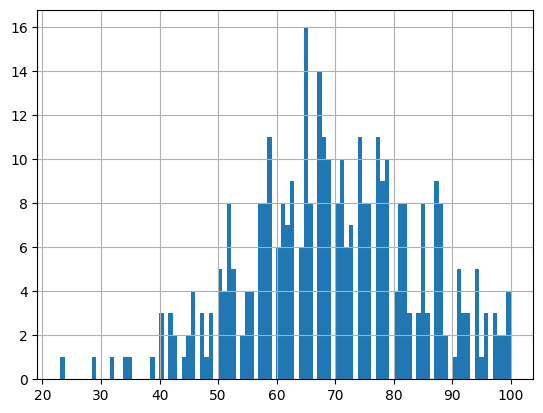

In [33]:
df_comleted['math score'].hist(bins=100)

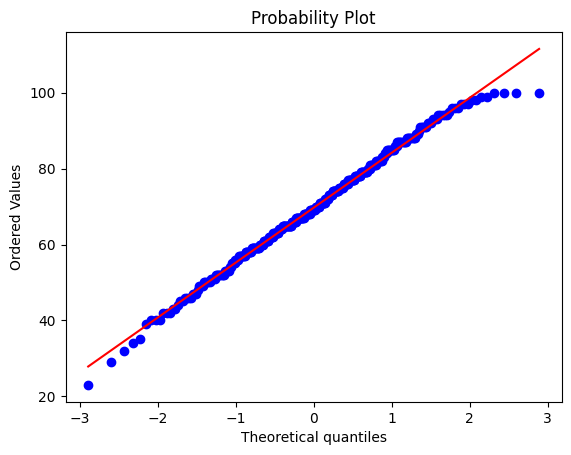

In [34]:
import matplotlib.pyplot as plt
stats.probplot(df_comleted['math score'], dist='norm', plot=plt)
plt.show()

<Axes: >

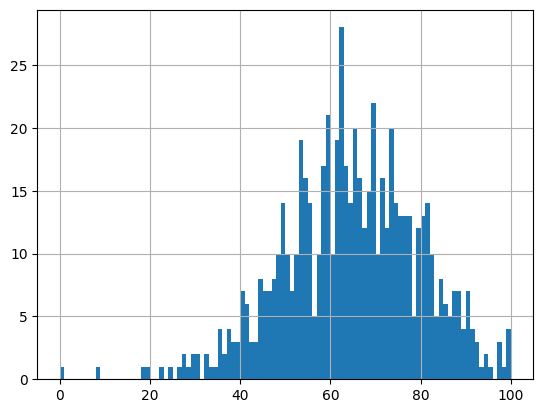

In [31]:
df_none['math score'].hist(bins=100)

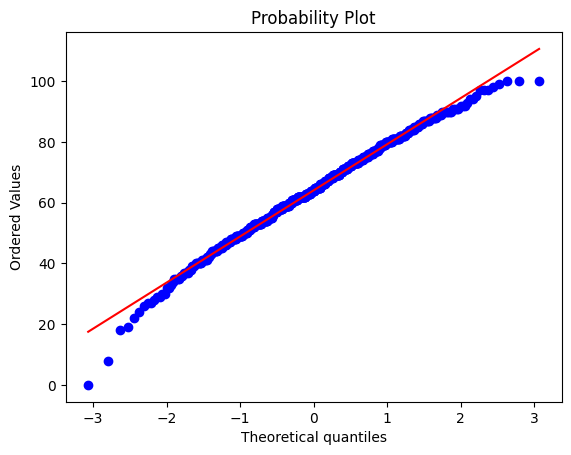

In [35]:
stats.probplot(df_none['math score'], dist='norm', plot=plt)
plt.show()

In [36]:
import numpy as np


n, _ = df_comleted.shape

result = stats.norm.interval(
    0.95,
    loc=df_comleted['math score'].mean(),
    scale=df_comleted['math score'].std()/np.sqrt(n)
)
result

(np.float64(68.19924311246356), np.float64(71.19181834005042))

In [37]:
n, _ = df_none.shape

result = stats.norm.interval(
    0.95,
    loc=df_none['math score'].mean(),
    scale=df_none['math score'].std()/np.sqrt(n)
)
result

(np.float64(62.90269654553577), np.float64(65.25306669433962))